# Tirana Deal Finder — Cleaning & EDA (Session 1)

Exploring the raw dataset (`data/tirana_house_prices.json`) BEFORE any cleaning,
to understand its structure and problems, and to justify the rules used in
`backend/preprocessing.py` (bounds, null handling, POI/location features, etc.)

In [1]:
import sys; sys.path.append("..")
import os
os.chdir("..")  # project root, so relative paths (data/...) resolve correctly

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

from backend.preprocessing import load_raw, build_display_df, build_ml_df, run
from backend import poi

print("Working directory:", os.getcwd())

Working directory: c:\Users\sara\Desktop\Summer Schoool Fundamentals\tirana-deal-finder-main


## 1. Load raw data and inspect

In [2]:
df = load_raw()  # RAW, no cleaning applied yet

print("=== HEAD ===")
print(df.head().T)

print("\n=== INFO ===")
df.info()

print("\n=== DESCRIBE ===")
print(df.describe())

print("\n=== % MISSING PER COLUMN ===")
print((df.isna().mean() * 100).round(1).sort_values(ascending=False))

=== HEAD ===
                                                                                                    0  \
main_property_description_text_content_original...  | Përshkrimi i apartamentit:\n\n♦Sallon i boll...   
main_property_floor                                                                               2.0   
main_property_furnishing_status                                                       fully_furnished   
main_property_has_carport                                                                        None   
main_property_has_elevator                                                                       True   
main_property_has_garage                                                                         None   
main_property_has_garden                                                                         None   
main_property_has_parking_space                                                                  None   
main_property_has_terrace                 

## 2. Price distribution

Right-skewed as expected for real estate prices — this is why `model.py` trains
on `log1p(price)` instead of raw price (`USE_LOG_TARGET = True`).

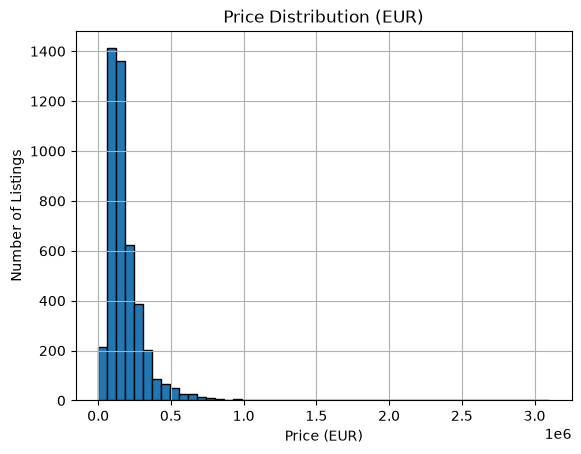

In [3]:
df["price_in_euro"].hist(bins=50, edgecolor="black")
plt.title("Price Distribution (EUR)")
plt.xlabel("Price (EUR)")
plt.ylabel("Number of Listings")
plt.show()

## 3. Square meters distribution

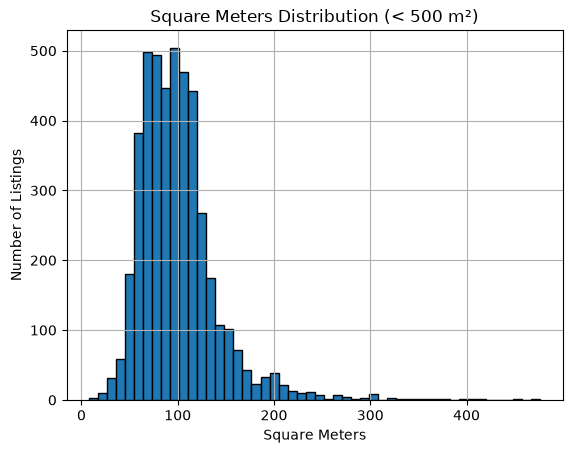

In [4]:
df[df["main_property_property_square"] < 500]["main_property_property_square"].hist(bins=50, edgecolor="black")
plt.title("Square Meters Distribution (< 500 m²)")
plt.xlabel("Square Meters")
plt.ylabel("Number of Listings")
plt.show()

## 4. Square meters vs price

Filtered to < 500 m² — a handful of extreme outliers (up to 50,000 m²) otherwise
compress the whole plot into one corner. A clear positive relationship shows up,
with variance increasing at higher sqm (same size, very different prices) —
this is the first hint that sqm alone isn't enough to explain price; location
matters too (confirmed later by the distance/location-score correlation).

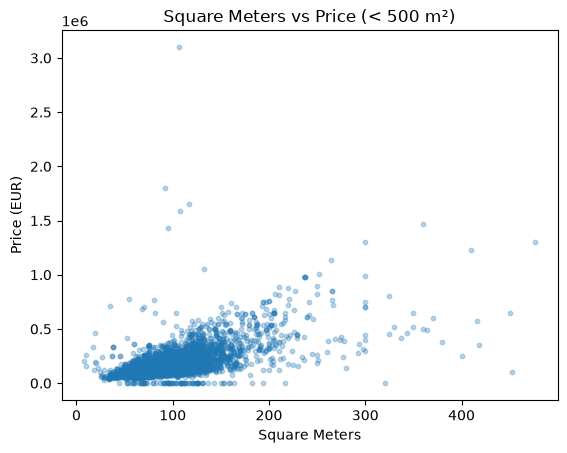

In [5]:
mask = df["main_property_property_square"] < 500
plt.scatter(df[mask]["main_property_property_square"], df[mask]["price_in_euro"], alpha=0.3, s=10)
plt.xlabel("Square Meters")
plt.ylabel("Price (EUR)")
plt.title("Square Meters vs Price (< 500 m²)")
plt.show()

## 5. Price boxplot (outlier detection)

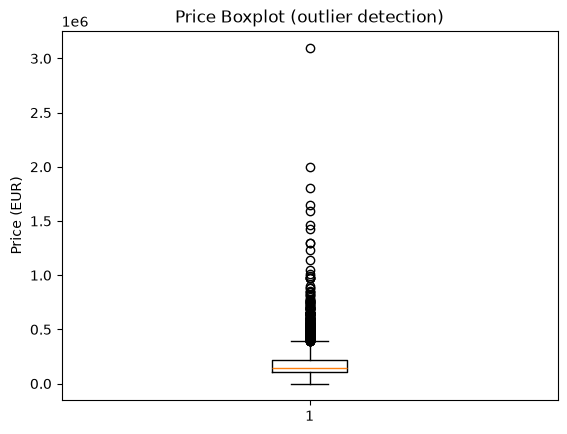

In [6]:
plt.boxplot(df["price_in_euro"].dropna())
plt.title("Price Boxplot (outlier detection)")
plt.ylabel("Price (EUR)")
plt.show()

## 6. Correlation matrix — raw vs filtered

On raw (unfiltered) data, `square_meters` correlates with price at only ~0.01 —
misleadingly weak, because a few extreme outliers (e.g. 50,000 m² listings)
distort the whole correlation. After filtering to a plausible range, sqm jumps
to ~0.64. This is concrete evidence that outlier removal isn't optional — it's
a prerequisite for the model (and even for basic statistics) to see the real
signal in the data.

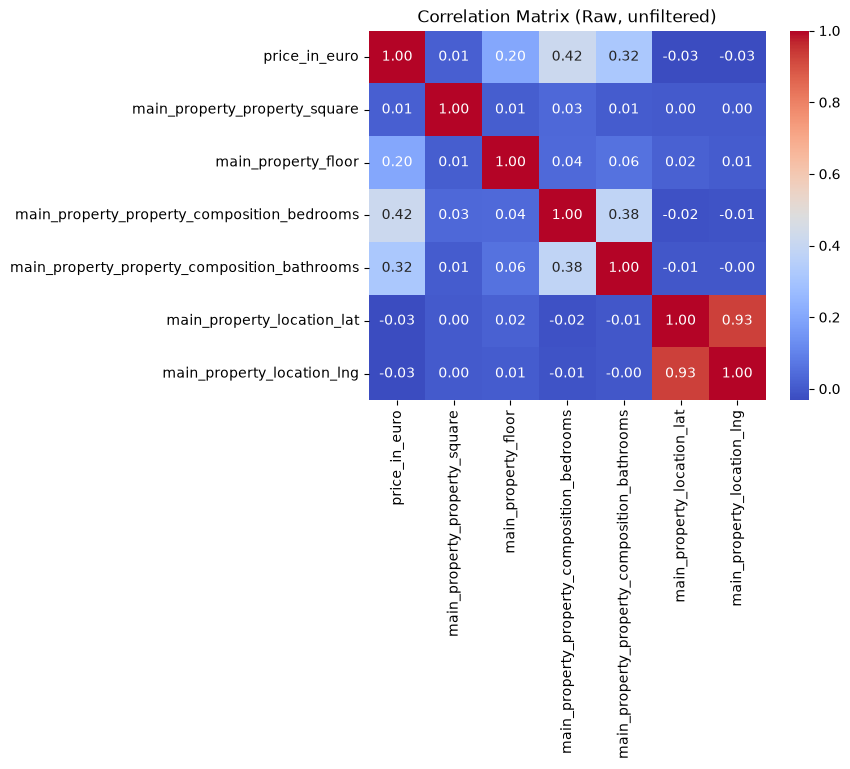

In [7]:
numeric_cols = ["price_in_euro", "main_property_property_square", "main_property_floor",
                 "main_property_property_composition_bedrooms",
                 "main_property_property_composition_bathrooms",
                 "main_property_location_lat", "main_property_location_lng"]

corr_raw = df[numeric_cols].corr()
sns.heatmap(corr_raw, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix (Raw, unfiltered)")
plt.show()

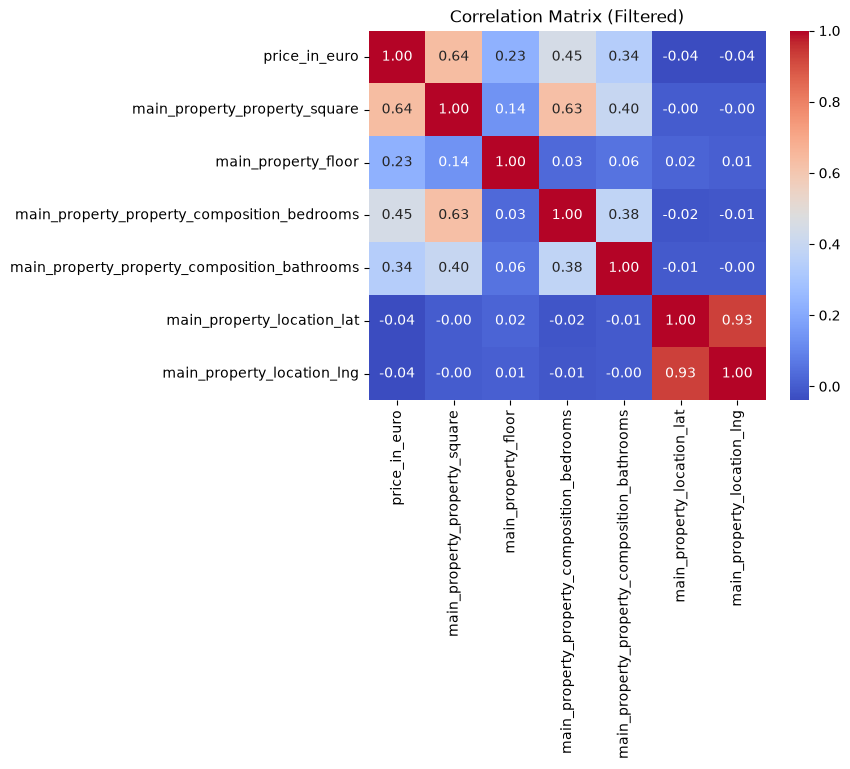

In [8]:
filtered = df[(df["main_property_property_square"] < 500) & (df["price_in_euro"] < 1_000_000)]

corr_filtered = filtered[numeric_cols].corr()
sns.heatmap(corr_filtered, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix (Filtered)")
plt.show()

## 7. Composition field sentinel check (bedrooms / bathrooms)

`-1` appears as a distinct value alongside `0` in these fields, which raised
the question of whether `-1` is a data-entry error (fixed with `abs()`) or an
"unspecified" sentinel (should become NaN). Tested both in `preprocessing.py`;
`abs()` (the professor's original approach) was kept, since converting to NaN
+ median imputation gave a negligible MAE difference (52,624 vs 52,635).

In [9]:
for col in ["main_property_property_composition_bedrooms",
            "main_property_property_composition_bathrooms"]:
    print(col)
    print(df[col].value_counts(dropna=False).sort_index())
    print()

main_property_property_composition_bedrooms
main_property_property_composition_bedrooms
-1.0      54
 0.0      29
 1.0    1301
 2.0    2348
 3.0     663
 4.0      60
 5.0       4
 6.0       5
 7.0       4
 8.0       1
 NaN      36
Name: count, dtype: int64

main_property_property_composition_bathrooms
main_property_property_composition_bathrooms
-1.0     353
 0.0      52
 1.0    2282
 2.0    1688
 3.0      79
 4.0      12
 5.0       2
 7.0       1
 NaN      36
Name: count, dtype: int64



## 8. Distance to city center

Using the haversine distance from each listing's coordinates to Skanderbeg
Square. Coordinates with `lat=0`/`lng=0` (missing-location sentinel) and a
handful of listings with coordinates in other cities entirely (e.g. Prague)
are excluded before computing correlation.

In [10]:
valid_coords = (df["main_property_location_lat"] != 0) & (df["main_property_location_lng"] != 0)

dist = poi.haversine_distance(
    df.loc[valid_coords, "main_property_location_lat"],
    df.loc[valid_coords, "main_property_location_lng"],
    *poi.CITY_CENTER
)
close_enough = dist <= 20  # drop bad-geocoding outliers (one pair even lands in Prague)

print(dist[close_enough].describe())

corr_dist = pd.DataFrame({
    "price_in_euro": df.loc[valid_coords, "price_in_euro"][close_enough],
    "dist_to_center_km": dist[close_enough],
}).corr()
print("\nCorrelation with price:")
print(corr_dist)

count    4452.000000
mean        2.415072
std         1.687623
min         0.028846
25%         1.306958
50%         2.068912
75%         2.975289
max        16.684087
dtype: float64

Correlation with price:
                   price_in_euro  dist_to_center_km
price_in_euro           1.000000          -0.179021
dist_to_center_km      -0.179021           1.000000


## 9. Run the full pipeline: raw → display_df → ml_df

Shows the "funnel" — how many rows survive each stage, and confirms
`data/listings_clean.parquet` gets saved.

In [11]:
display_df, ml_df = run()

print(f"Raw:         {len(df):>5} rows")
print(f"Display:     {len(display_df):>5} rows")
print(f"ML (final):  {len(ml_df):>5} rows")
print(f"\nML columns: {list(ml_df.columns)}")

Raw:          4505 rows
Display:      4505 rows
ML (final):   4329 rows

ML columns: ['listing_id', 'price_in_euro', 'square_meters', 'bedrooms', 'bathrooms', 'floor', 'furnishing_status', 'has_elevator', 'has_terrace', 'has_carport', 'has_garage', 'has_garden', 'has_parking_space', 'address', 'latitude', 'longitude', 'property_status', 'property_type', 'description', 'dist_to_center_km', 'zone', 'dist_to_hospital_km', 'dist_to_school_km', 'dist_to_bank_km', 'dist_to_park_km', 'dist_to_mall_km', 'location_score']


## 10. Median price by zone

Required by the course roadmap ("Plot the price distribution and median price
by zone"). Zone here is assigned by nearest-neighborhood-center coordinates
(`poi.assign_zones`), not by text-matching the address — address text-matching
only tagged ~23% of listings with a known zone (most addresses are street
names, not neighborhood names), so coordinate-based assignment is used instead.

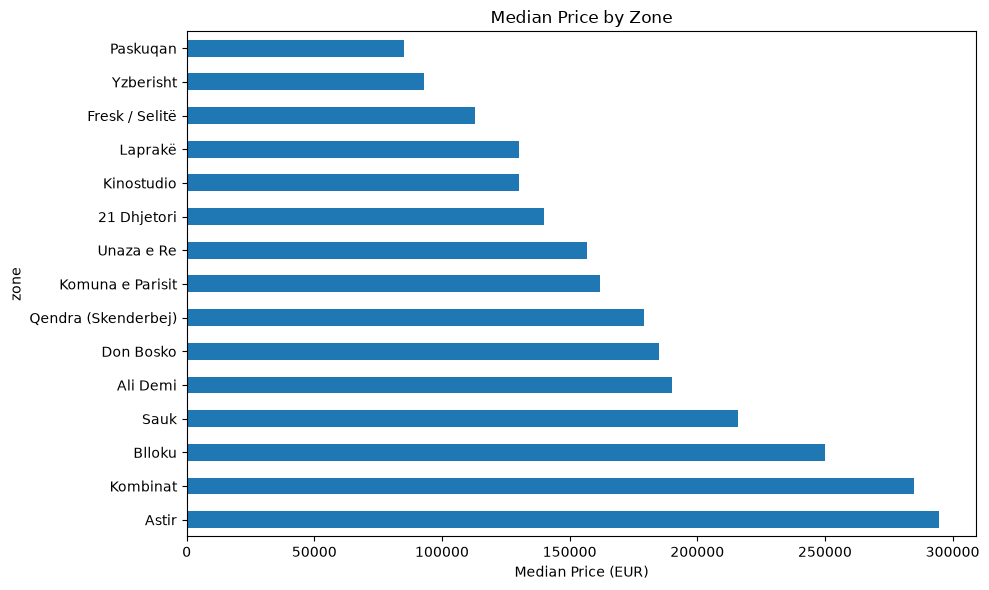

zone
Astir                  294500.0
Kombinat               285000.0
Blloku                 250000.0
Sauk                   216000.0
Ali Demi               190000.0
Don Bosko              185000.0
Qendra (Skenderbej)    179000.0
Komuna e Parisit       162000.0
Unaza e Re             157000.0
21 Dhjetori            140000.0
Kinostudio             130000.0
Laprakë                130000.0
Fresk / Selitë         113000.0
Yzberisht               93000.0
Paskuqan                85000.0
Name: price_in_euro, dtype: float64


In [12]:
zone_prices = ml_df.groupby("zone")["price_in_euro"].median().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
zone_prices.plot(kind="barh")
plt.xlabel("Median Price (EUR)")
plt.title("Median Price by Zone")
plt.tight_layout()
plt.show()

print(zone_prices)

## 11. Model performance — before/after each change

Every feature/preprocessing decision above was tested against the same
`smoke_test.py` benchmark (MAE, RMSE, R²), so the impact of each step is
measurable rather than assumed.

,step,MAE,RMSE,R2,MAE_reduction_pct
0,Baseline (professor's build),52635,82135,0.502,0.0
1,+ dist_to_center_km,39934,62759,0.685,24.1
2,+ location_score (POI proximity),38667,60217,0.710,26.5
3,"+ zone (categorical, nearest-neighborhood)",36483,59280,0.719,30.7


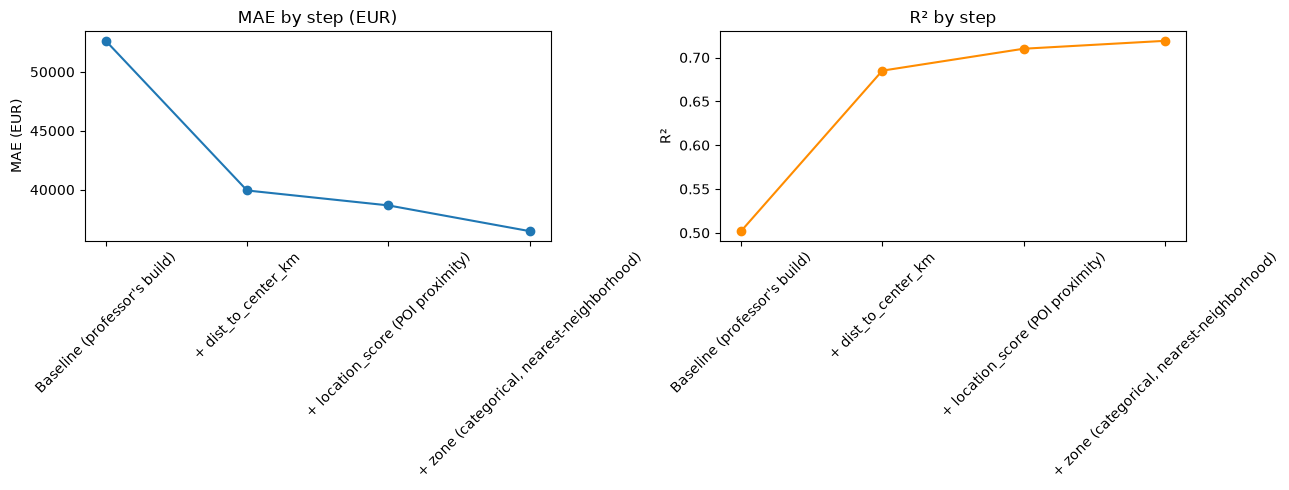

Total MAE reduction: 16,152 EUR (30.7%)
Total R2 improvement: 0.217


In [13]:
results = pd.DataFrame([
    {"step": "Baseline (professor's build)",              "MAE": 52635, "RMSE": 82135, "R2": 0.502},
    {"step": "+ dist_to_center_km",                        "MAE": 39934, "RMSE": 62759, "R2": 0.685},
    {"step": "+ location_score (POI proximity)",           "MAE": 38667, "RMSE": 60217, "R2": 0.710},
    {"step": "+ zone (categorical, nearest-neighborhood)", "MAE": 36483, "RMSE": 59280, "R2": 0.719},
])
results["MAE_reduction_pct"] = (
    (results["MAE"].iloc[0] - results["MAE"]) / results["MAE"].iloc[0] * 100
).round(1)

display(results)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(results["step"], results["MAE"], marker="o")
axes[0].set_title("MAE by step (EUR)")
axes[0].set_ylabel("MAE (EUR)")
axes[0].tick_params(axis="x", rotation=45)

axes[1].plot(results["step"], results["R2"], marker="o", color="darkorange")
axes[1].set_title("R² by step")
axes[1].set_ylabel("R²")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

print(f"Total MAE reduction: {results['MAE'].iloc[0] - results['MAE'].iloc[-1]:,.0f} EUR "
      f"({results['MAE_reduction_pct'].iloc[-1]}%)")
print(f"Total R2 improvement: {results['R2'].iloc[-1] - results['R2'].iloc[0]:.3f}")

## Summary — Session 1 findings

1. **4,505 raw listings, 24 columns.** Price and square-meters distributions
   are both right-skewed with a small number of extreme outliers.
2. **Outlier removal is a prerequisite, not optional** — raw correlation
   between `square_meters` and price was ~0.01 (misleadingly near-zero);
   after filtering, it jumped to ~0.64.
3. **`-1` in bedrooms/bathrooms** was tested as a possible "unspecified"
   sentinel vs a data-entry error; the fix made negligible difference to MAE,
   so the original `abs()` approach was kept.
4. **Location was the single biggest missing signal.** Raw lat/lng correlated
   ~0 with price (relationship is non-linear), but `dist_to_center_km`
   (haversine distance to Skanderbeg Square) correlates at ~-0.18 after
   filtering bad coordinates, and became the largest single driver of model
   improvement (R² 0.502 → 0.685 on its own).
5. **POI proximity + zone features** (backend/poi.py: distance to hospitals,
   schools, banks, parks, malls; a combined location_score; and a
   coordinate-based zone assignment) pushed R² further to ~0.72 and MAE down
   from €52,635 (baseline) to ~€36,500.